In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as plt
import seaborn as sns


---
# 1. Análisis del DataFrame

---
## Lectura del dataset

In [2]:
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv'

df = pd.read_csv(url)

print('Shape del dataset:', df.shape)
df.head()

Shape del dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

In [3]:
# Tipos de datos, columnas y memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# Estadísticas descriptivas de todas las columnas numéricas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Conteo de valores nulos por columna
# isnull() e isna() son equivalentes
print('Nulos con isnull():')
print(df.isnull().sum())
print('\nNulos con isna():')
print(df.isna().sum())

Nulos con isnull():
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Nulos con isna():
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


3. Número de variables del dataset y tipo

In [6]:
print(f'Número total de variables (columnas): {df.shape[1]}')
print(f'Número total de observaciones (filas): {df.shape[0]}')
print('\nTipo de cada variable:')
print(df.dtypes)
print('\nResumen por tipo:')
print(df.dtypes.value_counts())

# Conclusión esperada:
# - 9 variables numéricas (float64 / int64)
# - 1 variable categórica (object): ocean_proximity

Número total de variables (columnas): 10
Número total de observaciones (filas): 20640

Tipo de cada variable:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Resumen por tipo:
float64    9
str        1
Name: count, dtype: int64


4. ¿Existen valores faltantes? ¿En qué variables y cuántos?

In [7]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Cantidad de nulos': nulos,
    'Porcentaje (%)': nulos_pct.round(2)
})

print('Variables con valores faltantes:')
print(resumen_nulos[resumen_nulos['Cantidad de nulos'] > 0])

# Conclusión esperada:
# total_bedrooms tiene ~207 valores nulos (~1% del dataset)

Variables con valores faltantes:
                Cantidad de nulos  Porcentaje (%)
total_bedrooms                207             1.0


5. Elementos únicos en la columna `ocean_proximity`

In [8]:
print('Valores únicos en ocean_proximity:')
print(df['ocean_proximity'].unique())

print('\nConteo de cada categoría:')
print(df['ocean_proximity'].value_counts())

Valores únicos en ocean_proximity:
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Conteo de cada categoría:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


6. Promedio de columnas agrupado por `ocean_proximity` con groupby

In [9]:
cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
        'population', 'households', 'median_income', 'median_house_value']

# Promedio de cada columna por categoría de ocean_proximity
promedios = df.groupby('ocean_proximity')[cols].mean().round(2)
print('Promedio por categoría de ocean_proximity:')
promedios

Promedio por categoría de ocean_proximity:


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.28,2628.34,546.54,1520.29,517.74,4.23,240084.29
INLAND,24.27,2717.74,533.88,1391.05,477.45,3.21,124805.39
ISLAND,42.40,1574.60,420.40,668.00,276.60,2.74,380440.00
NEAR BAY,37.73,2493.59,514.18,1230.32,488.62,4.17,259212.31
NEAR OCEAN,29.35,2583.70,538.62,1354.01,501.24,4.01,249433.98


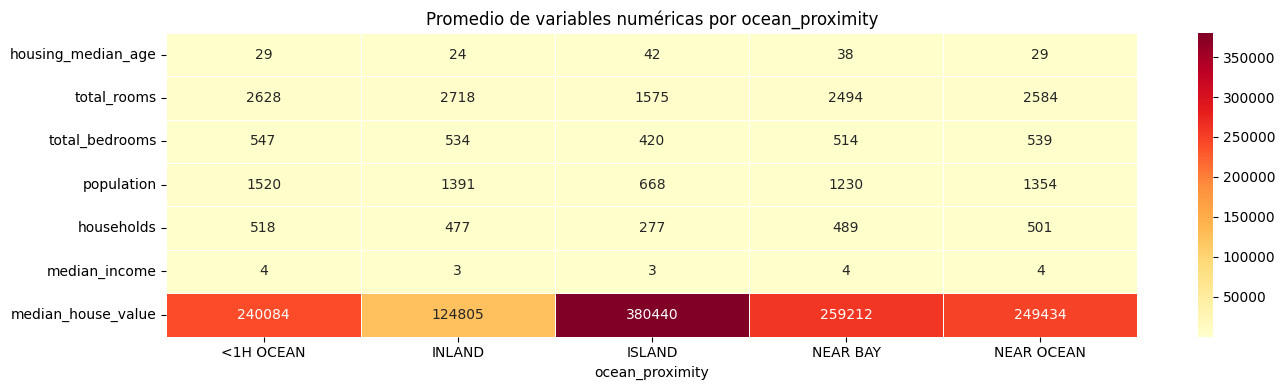

In [10]:
# Visualizar los promedios en un heatmap para comparar rápidamente
plt.figure(figsize=(14, 4))
sns.heatmap(
    promedios.T,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Promedio de variables numéricas por ocean_proximity')
plt.tight_layout()
plt.show()

7. Histograma para cada columna con seaborn

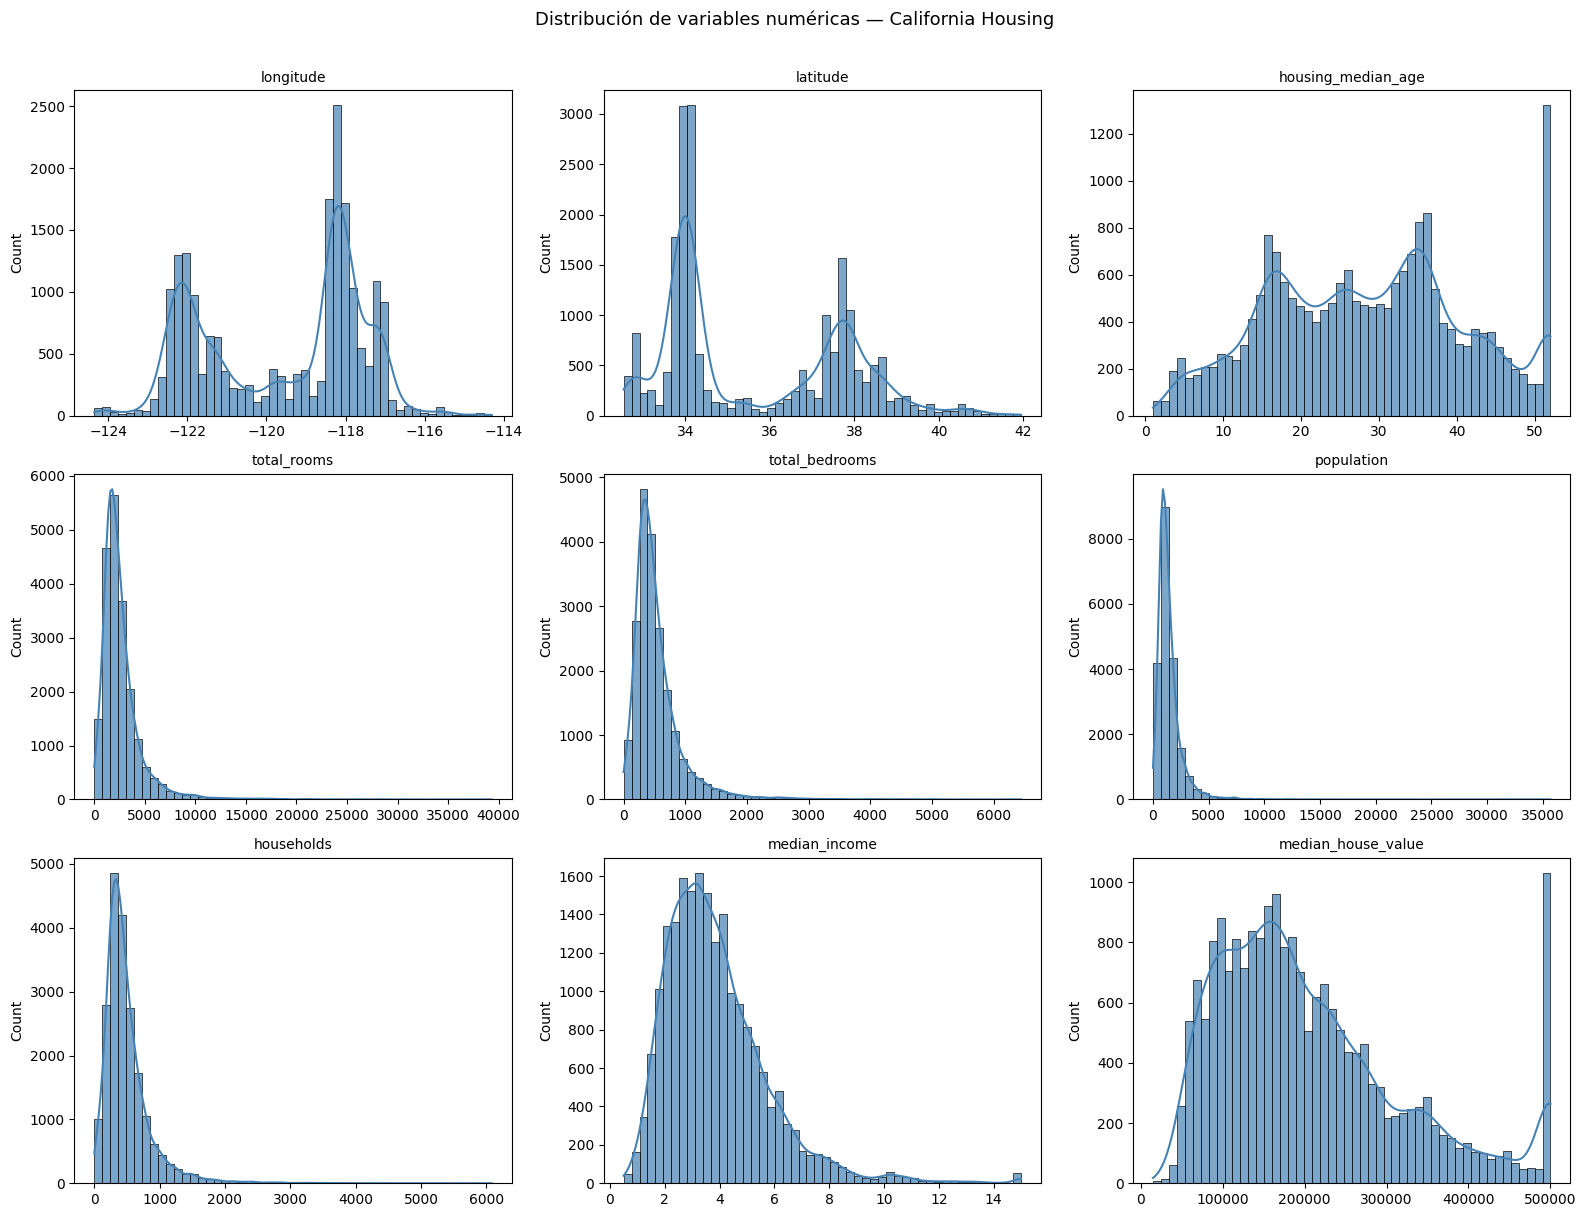

In [11]:
cols_num = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.histplot(df[col].dropna(), bins=50, kde=True,
                 ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Ocultar ejes sobrantes si los hay
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas — California Housing', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Nota: median_house_value muestra un techo en 500,000 USD
# (los valores iguales o superiores fueron truncados en el censo)

8.  Diagrama de caja (boxplot) de `median_house_value` por `ocean_proximity`

**Recordatorio del lab:**
- Q1: 25% de los datos (bigote inferior → caja)
- Q2: mediana (línea dentro de la caja)
- Q3: 75% de los datos (caja → bigote superior)
- IQR = Q3 − Q1
- Outliers: valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR]

**Ejemplo del lab:**

N = 24
T ordenado: [52 57 57 58 63 66 66 67 67 68 69 70 70 70 70 72 73 75 75 76 76 78 79 89]
N/4 = 6.0

Q1=66.0  Q3=75.0  IQR=9.0
Límite superior (lab): 88.5
Límite inferior (lab): 52.5


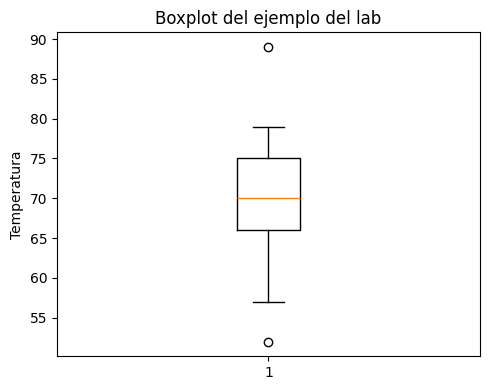

In [12]:
# Ejemplo de cálculo manual de cuartiles e IQR (del lab)
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68,
              69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(f'N = {len(T)}')
print(f'T ordenado: {Tsort}')
print(f'N/4 = {len(T)/4}')

Q1 = np.percentile(T, 25)
Q3 = np.percentile(T, 75)
IQR = Q3 - Q1
print(f'\nQ1={Q1}  Q3={Q3}  IQR={IQR}')

IQR_lab = 9   # valor del lab
max_ = 75 + 1.5 * IQR_lab
min_ = 66 - 1.5 * IQR_lab
print(f'Límite superior (lab): {max_}')
print(f'Límite inferior (lab): {min_}')

plt.figure(figsize=(5, 4))
plt.boxplot(T)
plt.title('Boxplot del ejemplo del lab')
plt.ylabel('Temperatura')
plt.tight_layout()
plt.show()